In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path
src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

# Análisis exploratorio (EDA) - Part 1
Dada la información extraída y almacenada en formato .parquet, se realiza un análisis exploratorio sobre la información recolectada

## Importación de librerias necesarias

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from src.utils import SparkUtils
from pyspark.sql import functions as F, types as T, DataFrame, Window
import json
from src.utils.dataframe import check_null_values, check_empty_arrays
import os

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [4]:
spark_utils = SparkUtils('quality')
spark = spark_utils.spark

## Análisis información de productos

### Cargar información de items

In [5]:
meta_items = spark.read.format('delta').load(spark_utils.path('meta_items'))

In [6]:
meta_items.filter(F.size('description') == F.lit(0)).limit(1000).toPandas()

,title,main_category,features,description,average_rating,rating_number,price,store,parent_asin,categories,details,images
0,Microsoft Virtual PC for Mac 6.1 [Old Version],Software,[],[],3.0,7,NaN,Microsoft,B0000AI0NV,"[Software, Microsoft, All Microsoft]","{""Is Discontinued By Manufacturer"":""Yes"",""Lang...","[{""thumb"":""https://m.media-amazon.com/images/I..."
1,Made E-Z Deluxe Business Forms,Software,[],[],5.0,1,NaN,Made E-Z Software,1563827336,"[Software, Business & Office, Legal]","{""Is Discontinued By Manufacturer"":""No"",""Packa...","[{""thumb"":""https://m.media-amazon.com/images/I..."
2,Sibelius 4 Educational Edition,Software,"[Complete software for writing, playing, print...",[],3.0,4,NaN,Sibelius,B000B3Z2ZO,"[Software, Music, Instrument Instruction]","{""Package Dimensions"":""10.1 x 7.1 x 1.9 inches...","[{""thumb"":""https://m.media-amazon.com/images/I..."
3,DirectSystems Compatible with WIN 8.1 Compatib...,Software,[You are purchasing a custom Windows 8.1 Any V...,[],3.6,204,NaN,DirectSystems,B012URKXS4,"[Software, Utilities, Backup]","{""Is Discontinued By Manufacturer"":""No"",""Date ...","[{""thumb"":""https://m.media-amazon.com/images/I..."
4,Genuine Microsoft Windows 8 Pro X64 /64 Bit Li...,Software,[],[],4.5,7,NaN,Microsoft,B00EYNPY6O,"[Software, Microsoft, All Microsoft]","{""Is Discontinued By Manufacturer"":""No"",""Packa...","[{""thumb"":""https://m.media-amazon.com/images/I..."
...,...,...,...,...,...,...,...,...,...,...,...,...
995,AE WORDPERFECT OFFICE-2002 CD W9X/NT,Software,"[Voice-powered word processing, Web-ready slid...",[],3.4,4,99.99,Corel,B00006HT8W,"[Software, Corel, All Corel]","{""Is Discontinued By Manufacturer"":""Yes"",""Pack...","[{""thumb"":""https://m.media-amazon.com/images/I..."
996,SiteSpinner Pro: Professional Web Development ...,Software,[],[],3.1,128,NaN,Virtual Mechanics,B001PIAUEW,[],"{""Is Discontinued By Manufacturer"":""No"",""Packa...","[{""thumb"":""https://m.media-amazon.com/images/I..."
997,Ipswitch WS_FTP Pro V8 Single User,Software,[],[],4.5,3,NaN,"Ipswitch, Inc",B0000C66VY,[],"{""Is Discontinued By Manufacturer"":""No"",""Packa...","[{""thumb"":""https://m.media-amazon.com/images/I..."
998,Band-in-a-Box 2013 Everything Pak [Old Version],Software,[],[],5.0,1,NaN,PG Music Inc.,B00BY0G374,[],"{""Product Dimensions"":""9.88 x 3.38 x 6.25 inch...","[{""thumb"":""https://m.media-amazon.com/images/I..."


### Vista general de columnas disponibles

In [7]:
" | ".join( meta_items.columns )

'title | main_category | features | description | average_rating | rating_number | price | store | parent_asin | categories | details | images'

### Examinación de valores nulos en columnas

In [8]:
columns_data_nulls = []
for col in meta_items.columns:
    null_count, non_null_count, _ = check_null_values( meta_items, col)
    columns_data_nulls.append( (col, non_null_count, null_count) )
def build_dict(x):
    total = x[1] + x[2]
    return {
        "values": (x[1] / total, x[2] / total),
        "label": x[0],
        "title": x[0]
    }
df_columns_data_nulls = list(map(
    lambda x: build_dict(x),
    columns_data_nulls
))
pd_df_columns_data_nulls = pd.DataFrame(
    columns_data_nulls,
    columns=["Column", "Non-null", "Null"]
)

In [9]:
pd_df_columns_data_nulls

,Column,Non-null,Null
0,title,3125022,0
1,main_category,2893452,231570
2,features,3125022,0
3,description,3125022,0
4,average_rating,3124997,25
5,rating_number,3122063,2959
6,price,909648,2215374
7,store,3092643,32379
8,parent_asin,3125022,0
9,categories,3125022,0


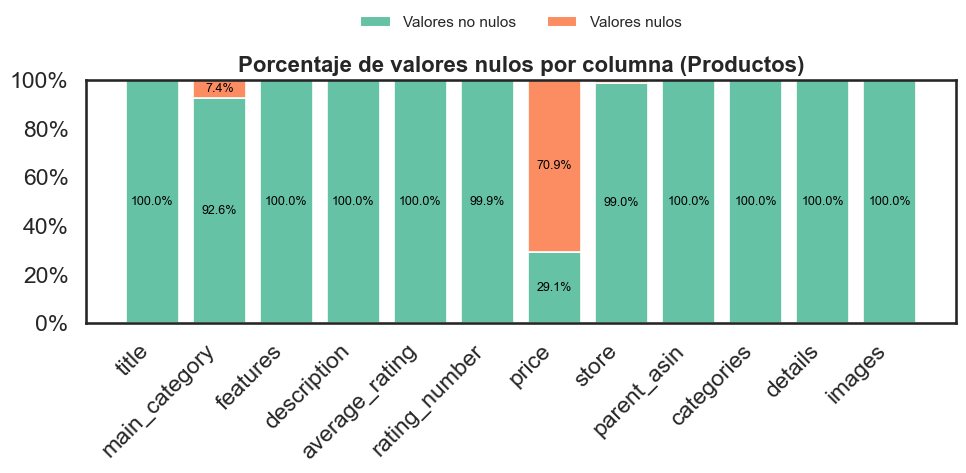

In [10]:
from src.utils.visualization.Barplot import BarPlot
percentage_plot = BarPlot()
percentage_plot.prepare_percent_show(
    title = "Porcentaje de valores nulos por columna (Productos)",
)
percentage_plot.plot(
    df_columns_data_nulls, legend_labels = ["Valores no nulos", "Valores nulos"]
)

### Examinación de tamaños de arreglo para campos que se encuentran en formato de arreglo

In [11]:
columns_data_empties = []
for col in [
    "features", "description", "categories", "images"
]:
    empty_count, non_empty_count, _ = check_empty_arrays( meta_items, col)
    columns_data_empties.append( (col, non_empty_count, empty_count) )
def build_dict(x):
    total = x[1] + x[2]
    return {
        "values": (x[1] / total, x[2] / total),
        "label": x[0],
        "title": x[0]
    }
df_columns_data_empties = list(map(
    lambda x: build_dict(x),
    columns_data_empties
))
pd_df_columns_data_empties = pd.DataFrame(
    columns_data_empties,
    columns=["Column", "Non-empty", "Empty"]
)

In [12]:
pd_df_columns_data_empties

,Column,Non-empty,Empty
0,features,2165450,959572
1,description,1669143,1455879
2,categories,2664130,460892
3,images,3122215,2807


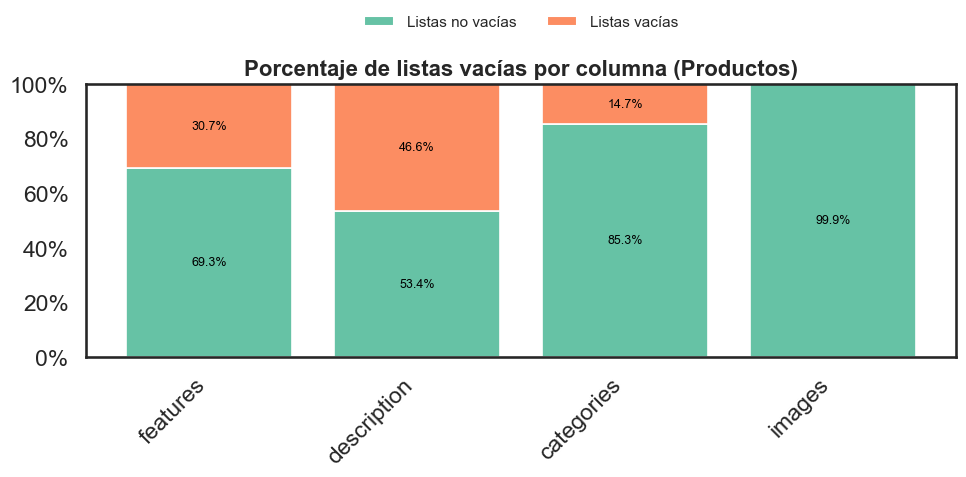

In [13]:
from src.utils.visualization.Barplot import BarPlot
percentage_plot = BarPlot()
percentage_plot.prepare_percent_show(
    title = "Porcentaje de listas vacías por columna (Productos)",
)
percentage_plot.plot(
    df_columns_data_empties, legend_labels = ["Listas no vacías", "Listas vacías"]
)

### Examinación de campo detalles

In [14]:
def get_json_length(str_obj):
    obj = json.loads(str_obj)
    return len(obj)
meta_items_json_length = (
    meta_items
        .select(
            F.col('*'), F.udf(get_json_length)(F.col('details')).alias('len')
        )
)

In [15]:
meta_items_details_empty = meta_items_json_length.filter(F.col('len') == 0).count()
meta_items_details_non_empty = meta_items_json_length.filter(F.col('len') > 0).count()
df_meta_items_details_empty = [meta_items_details_non_empty, meta_items_details_empty]

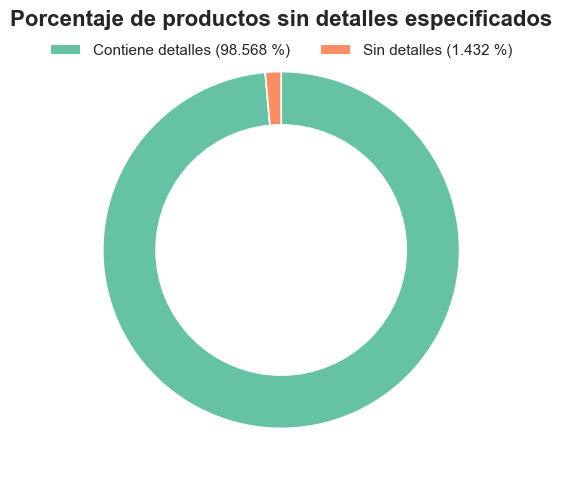

In [16]:
from src.utils.visualization.CircularPlot import CircularPlot
circular_plot = CircularPlot()
circular_plot.prepare_single_show(
    title = "Porcentaje de productos sin detalles especificados",
)
circular_plot.plot(
    df_meta_items_details_empty,
    legend_labels = [
        f"Contiene detalles ({(100 * meta_items_details_non_empty / (meta_items_json_length.count())):.3f} %)",
        f"Sin detalles ({(100 * meta_items_details_empty / (meta_items_json_length.count())):.3f} %)",
    ],
    col_size = 5, rows_size = 5,
    legend_y = 0.94
)

In [17]:
f"Cantidad de items con campo details sin elementos: {meta_items_json_length.filter(F.col('len') == 0).count()}"

'Cantidad de items con campo details sin elementos: 44763'

## Análisis información de reseñas

### Cargar información de items

In [18]:
reviews = spark.read.format('delta').load(spark_utils.path('reviews'))

### Vista general de columnas disponibles

In [19]:
" | ".join( reviews.columns )

'rating | title | text | timestamp | helpful_vote | parent_asin | images'

### Examinación de valores nulos en columnas

In [20]:
columns_data_nulls_reviews = []
for col in reviews.columns:
    null_count, non_null_count, _ = check_null_values( reviews, col)
    columns_data_nulls_reviews.append( (col, non_null_count, null_count) )
def build_dict(x):
    total = x[1] + x[2]
    return {
        "values": (x[1] / total, x[2] / total),
        "label": x[0],
        "title": f"{x[0]} - {(x[2] * 100 / total):.3f}%"
    }
df_columns_data_nulls_reviews = list(map(
    lambda x: build_dict(x),
    columns_data_nulls_reviews
))
pd_df_columns_data_nulls_reviews = pd.DataFrame(
    columns_data_nulls_reviews,
    columns=["Column", "Non-empty", "Empty"]
)

In [21]:
pd_df_columns_data_nulls_reviews

,Column,Non-empty,Empty
0,rating,74204685,0
1,title,74204685,0
2,text,74204685,0
3,timestamp,74204685,0
4,helpful_vote,74204685,0
5,parent_asin,74204685,0
6,images,74204685,0


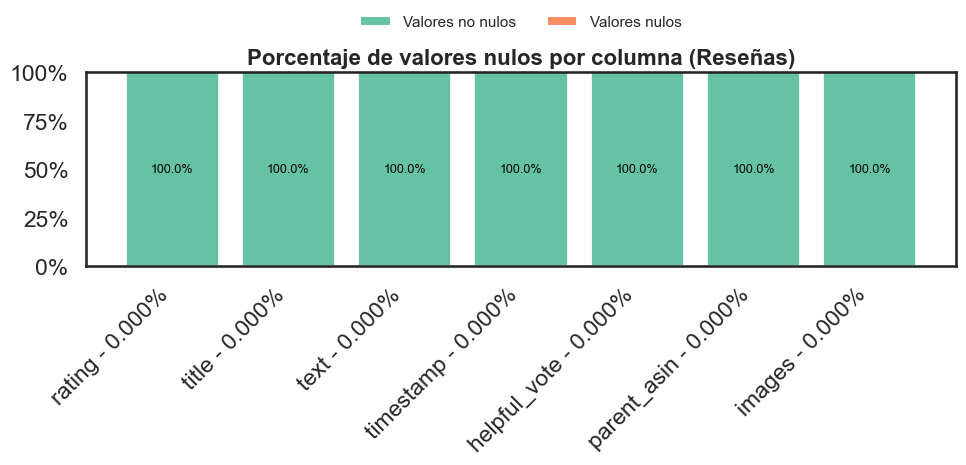

In [22]:
from src.utils.visualization.Barplot import BarPlot
percentage_plot = BarPlot()
percentage_plot.prepare_percent_show(
    title = "Porcentaje de valores nulos por columna (Reseñas)",
)
percentage_plot.plot(
    df_columns_data_nulls_reviews, legend_labels = ["Valores no nulos", "Valores nulos"]
)

In [23]:
columns_data_empty_reviews = []
for col in [
    "images"
]:
    empty_count, non_empty_count, _ = check_empty_arrays( reviews, col)
    columns_data_empty_reviews.append( (col, empty_count, non_empty_count) )
def build_dict(x):
    total = x[1] + x[2]
    return {
        "values": (x[1] / total, x[2] / total),
        "label": x[0],
        "title": f"{x[0]} - {(x[2] * 100 / total):.3f}%"
    }
df_columns_data_empties_reviews = list(map(
    lambda x: build_dict(x),
    columns_data_empty_reviews
))
pd_df_columns_data_empties_reviews = pd.DataFrame(
    columns_data_empty_reviews,
    columns=["Column", "Non-empty", "Empty"]
)

In [27]:
empty_count, non_empty_count

(70927443, 3277242)

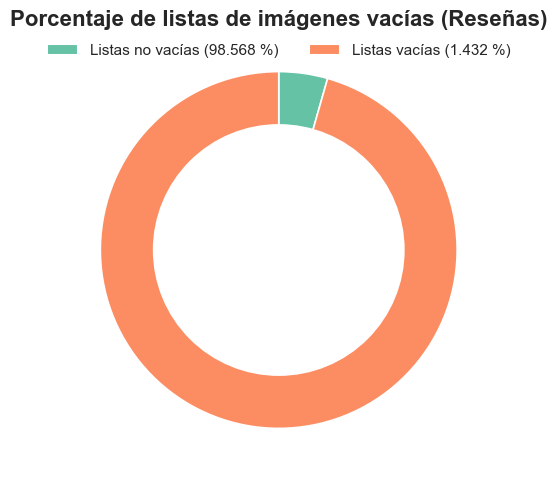

In [29]:
from src.utils.visualization.CircularPlot import CircularPlot
circular_plot = CircularPlot()
circular_plot.prepare_single_show(
    title = "Porcentaje de listas de imágenes vacías (Reseñas)",
)
circular_plot.plot(
    [non_empty_count, empty_count, ],
    legend_labels = [
        f"Listas no vacías ({100 * (meta_items_details_non_empty / (meta_items_json_length.count())):.3f} %)",
        f"Listas vacías ({100 * (meta_items_details_empty / (meta_items_json_length.count())):.3f} %)",
    ],
    col_size = 5, rows_size = 5,
    legend_y = 0.94
)